In [1]:
from sklearn.datasets._samples_generator import make_blobs
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

* make_blobs is a function used in machine learning to generate synthetic (fake) data for testing and   visualization.
* make_blobs creates clusters of points in space.

In [ ]:
X,Y=make_blobs(n_samples=200,centers=2,n_features=2,cluster_std=5,random_state=11)
m=200

In [3]:
X=(X-X.mean(axis=0))/X.std(axis=0)

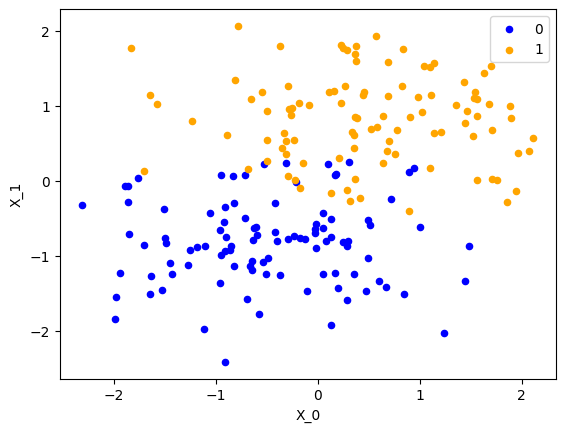

In [8]:
df =pd.DataFrame(dict(x=X[:, 0], Y=X[:, 1], label=Y))

# define colors
colors = {0: 'blue', 1: 'orange'}

# plot
fig, ax = plt.subplots()

grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='Y',
               label=key, color=colors[key])

plt.xlabel('X_0')
plt.ylabel('X_1')
plt.show()

In [9]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [10]:
#model
def hx(w,X):
    z=np.array(w[0]+w[1]*np.array(X[:,0])+w[2]*np.array(X[:,1]))
    return sigmoid(z)

In [11]:
#cost function
def cost(w,X,Y):
    y_pred=hx(w,X)   #assign the prediction value
    return -1*sum(Y*np.log(y_pred)+(1-Y)*np.log(1-y_pred))

In [17]:
def grad(w,X,Y):
    y_pred=hx(w,X)
    g=[0]*3
    g[0]=-1*sum(Y*(1-y_pred)-(1-Y)*y_pred)
    g[1]=-1*sum(Y*(1-y_pred)*X[:,0]-(1-Y)*y_pred*X[:,0])
    g[2]=-1*sum(Y*(1-y_pred)-(1-Y)*X[:,1]*y_pred*X[:,1])
    return g

In [18]:
def descent(w_new ,w_prev,lr):
    print(w_prev)
    print(cost(w_prev,X,Y))
    j=0
    while True:
        w_prev=w_new
        gg=grad(w_prev,X,Y)
        w0=w_prev[0]-lr*gg[0]
        w1=w_prev[1]-lr*gg[1]
        w2=w_prev[2]-lr*gg[2]
        # print(f"hello-{gg}")
        w_new=[w0,w1,w2]
        print(w_new)
        print(cost(w_new,X,Y))
        if(w_new[0]-w_prev[0])**2+(w_new[1]-w_prev[1])**2+(w_new[2]-w_prev[2])**2<pow(10,-6):
            return w_new
        if j>100:
            return w_new
        j+=1

In [19]:
w=[1,1,1]

In [20]:
w=descent(w,w,.001)
print(w)

[1, 1, 1]
81.31083797669591
[np.float64(0.968854126606655), np.float64(1.004508561555801), np.float64(0.9791865268478331)]
81.10890506617118
[np.float64(0.9384821860116781), np.float64(1.0087319822494258), np.float64(0.9589149312304998)]
80.94072855773223
[np.float64(0.9088760880541391), np.float64(1.0126841989325677), np.float64(0.9391833582814307)]
80.80436483093956
[np.float64(0.8800273040855799), np.float64(1.0163788892432106), np.float64(0.9199894834347359)]
80.69789596143944
[np.float64(0.851926878112564), np.float64(1.019829447289861), np.float64(0.9013305150134483)]
80.61943357269644
[np.float64(0.8245654405803506), np.float64(1.023048959869471), np.float64(0.8832032002230564)]
80.5671226067921
[np.float64(0.7979332245520354), np.float64(1.026050183636344), np.float64(0.8656038342483886)]
80.53914496414411
[np.float64(0.7720200840229818), np.float64(1.0288455236058758), np.float64(0.8485282721422719)]
80.53372296814587
[np.float64(0.746815514103857), np.float64(1.03144701333185

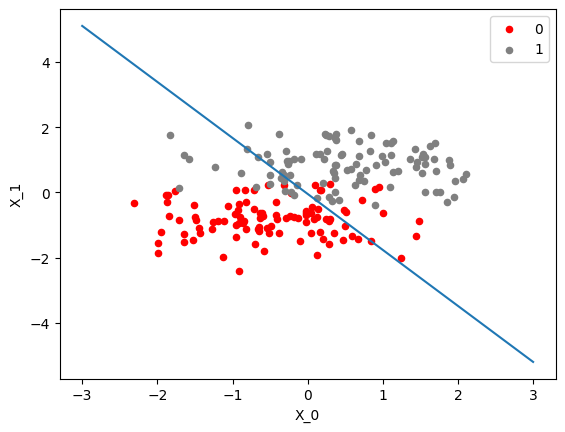

In [36]:
def graph(formula, x_range):
    x = np.array(x_range)
    y = formula(x)
    plt.plot(x, y)

# decision boundary formula
def my_formula(x):
    return (-w[0] - w[1] * x) / w[2] #w_2x_1 + w_1x_0 + w_0 = 0

# create dataframe
df = pd.DataFrame(dict(x=X[:, 0], y=X[:, 1], label=Y))

# colors for classes
colors = {0: 'red', 1: 'grey'}

# plot points
fig, ax = plt.subplots()
grouped = df.groupby('label')

for key,group in grouped:
    group.plot(ax=ax,kind='scatter',label=key,x='x',y='y',color=colors[key])
# plot decision boundary
graph(my_formula, np.linspace(-3, 3))

plt.xlabel('X_0')
plt.ylabel('X_1')
plt.show()